In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.stats import f
from scipy.stats import norm

In [32]:
def generate_sample(n: int) -> np.ndarray:
    answ = np.random.uniform(-1, 1, size=(n, 6))
    for i in range(n):
        mid = 2 + 3 * answ[i][0] - 2 * answ[i][1] + answ[i][2] + answ[i][3] - answ[i][4]
        y = np.random.normal(mid, 1.5)
        answ[i][5] = y
    return answ
    

In [33]:
n = 50
sample = generate_sample(n)
X = sample[:, :-1]
y = sample[:, -1]
precise = 3

In [34]:
class Regressor:
    def __init__(self, X: np.ndarray, y: np.ndarray, functions: list["function"], precise: float = 3, beta: float = 0.05) -> None:
        self.X = X
        self.y = y
        self.functions = functions
        self.beta = beta
        self.psi_matrix = np.array([[f(val) for f in self.functions] for val in self.X])
        self.F_inverted = self.findFInvertedMatrix()
        self.beta_estimations = self.findRegressionCoefficients()
        self.precise = precise

    def findFInvertedMatrix(self) -> np.ndarray:
        F_matrix = self.psi_matrix.T @ self.psi_matrix
        F_inverted_matrix = np.linalg.inv(F_matrix)

        return F_inverted_matrix

    def findRegressionCoefficients(self) -> np.ndarray:
        F_matrix = self.psi_matrix.T @ self.psi_matrix
        F_inverted_matrix = np.linalg.inv(F_matrix)
        beta_estimations = F_inverted_matrix @ self.psi_matrix.T @ self.y

        return beta_estimations
    
    def findErrors(self) -> np.ndarray:
        self.beta_estimations = self.findRegressionCoefficients()
        y_hat = self.psi_matrix @ self.beta_estimations
        return self.y - y_hat
    
    def findRSS(self) -> float:
        errors = self.findErrors()
        return errors.T @ errors
    
    def findTSS(self) -> float:
        y_avg = np.average(self.y)
        return np.sum((y_avg - self.y) ** 2)
    
    def findRSquare(self) -> float:
        TSS = self.findTSS()
        RSS = self.findRSS()
        return np.round((TSS - RSS) / TSS, self.precise)
    
    def checkCoefficientSignificance(self, ind: int) -> float:
        RSS = self.findRSS()
        F_inverted_i_i = self.F_inverted[ind, ind]
        beta_estimated = self.beta_estimations[ind]
        n = self.X.shape[0]
        p = len(self.functions)
        delta_estimation = abs(beta_estimated / np.sqrt(RSS * F_inverted_i_i / (n - p)))
        p_value = t.cdf(-delta_estimation, n - p) + t.sf(delta_estimation, n - p)
        return np.round(p_value, self.precise)
    
    def findConfidenceInterval(self, point: np.ndarray) -> tuple[float]:
        prediction = self.getPrediction(point)
        n = self.X.shape[0]
        p = len(self.functions)
        RSS = self.findRSS()
        func_vals = np.array([func(point) for func in self.functions])
        val = np.sqrt(RSS * (1 + func_vals @ self.F_inverted @ func_vals.T) / (n - p))
        left_bound = (1 - self.beta) / 2
        right_bound = (1 + self.beta) / 2
        left_percentile = t.ppf(left_bound, n - p)
        right_percentile = t.ppf(right_bound, n - p)

        left_value = prediction - val * right_percentile
        right_value = prediction - val * left_percentile

        return (left_value, right_value)

    def getPrediction(self, point: np.ndarray) -> float:
        func_vals = np.array([func(point) for func in self.functions])
        prediction = self.beta_estimations.T @ func_vals
        return prediction
    
    def getPredictions(self, points: np.ndarray) -> np.ndarray:
        predictions = [self.getPrediction(point) for point in points]
        return predictions
    
    def findIndependance(self) -> float:
        errors = self.findErrors()
        n = errors.shape[0]
        inv_count = 0
        for i in range(n):
            for j in range(i + 1, n):
                if (errors[j] < errors[i]):
                    inv_count += 1
        
        middle_inv_count = n * (n - 1) // 4

        delta = abs((inv_count - middle_inv_count) / np.sqrt(n ** 3 / 36))
        p_value = norm.cdf(-delta) + norm.sf(delta)
        return p_value
    
    def printRegr(self) -> None:
        answ = f"{np.round(self.beta_estimations[0], self.precise)}"
        for i in range(1, self.beta_estimations.shape[0]):
            coef = self.beta_estimations[i]
            answ += f" + {str(np.round(coef, self.precise))}*x_{i}"
        print("y =", answ)

In [35]:
func0 = lambda _: 1
func1 = lambda x: x[0]
func2 = lambda x: x[1]
func3 = lambda x: x[2]
func4 = lambda x: x[3]
func5 = lambda x: x[4]

а) проверка мультиколлинеарности

In [36]:
funcs = [func0, func1, func2, func3, func4]
for i in range(5):
    rng = []
    for j in range(5):
        if i == j: continue
        rng.append(j)
    regr = Regressor(sample[:, rng], sample[:, i], funcs)
    print(f"коэффициент детерминации для {i + 1}-ого фактора: {regr.findRSquare()}")
print("нет мультиколлинеарности")

коэффициент детерминации для 1-ого фактора: 0.099
коэффициент детерминации для 2-ого фактора: 0.049
коэффициент детерминации для 3-ого фактора: 0.135
коэффициент детерминации для 4-ого фактора: 0.015
коэффициент детерминации для 5-ого фактора: 0.014
нет мультиколлинеарности


b) проверка значимости коэффициентов и построение регрессии

In [37]:
funcs = [func0, func1, func2, func3, func4, func5]

regr = Regressor(sample[:, :-1], sample[:, -1], funcs)

regr.printRegr()
for i in range(len(funcs)):
    print(f"p-value для значимости {i}-ого коэффициента: {regr.checkCoefficientSignificance(i)}")

y = 1.834 + 3.586*x_1 + -2.466*x_2 + 1.24*x_3 + 0.661*x_4 + -0.964*x_5
p-value для значимости 0-ого коэффициента: 0.0
p-value для значимости 1-ого коэффициента: 0.0
p-value для значимости 2-ого коэффициента: 0.0
p-value для значимости 3-ого коэффициента: 0.0
p-value для значимости 4-ого коэффициента: 0.034
p-value для значимости 5-ого коэффициента: 0.006


c) коэффициент детерминации

In [38]:
def compareNarrowAndWideRegressions(regr_narrow: Regressor, regr_wide: Regressor) -> float:
    n = regr_wide.X.shape[0]
    RSS_narrow = regr_narrow.findRSS()
    RSS_wide = regr_wide.findRSS()
    p1 = len(regr_wide.functions)
    p0 = len(regr_narrow.functions)
    delta = ((RSS_narrow - RSS_wide) / (p1 - p0)) / ((RSS_wide) / (n - p1))
    p_value = f.sf(delta, p1 - p0, n - p1)
    return np.round(p_value, precise)

In [39]:
print(f"R^2 = {regr.findRSquare()}")

funcs_narrow = [func0]
regr_narrow = Regressor(X, y, funcs_narrow)
regr_wide = Regressor(X, y, funcs)
print(f"p-value = {compareNarrowAndWideRegressions(regr_narrow, regr_wide)}; нельзя считать коэффициенты регрессии незначимыми")

R^2 = 0.866
p-value = 0.0; нельзя считать коэффициенты регрессии незначимыми


d) доверительный интервал

In [40]:
regr = Regressor(X, y, funcs)
point = np.array([0, 0, 0, 0, 0])
prediction = regr.getPrediction(point)
print(f"значение в точке 0: {np.round(prediction, precise)}")
left_bound, right_bound = regr.findConfidenceInterval(point)
print(f"доверительный интервал: ({np.round(left_bound, precise)}, {np.round(right_bound, precise)})")

значение в точке 0: 1.834
доверительный интервал: (1.759, 1.908)


e) проверка предположения о независимости ошибок измерения

In [41]:
print(f"p_value = {np.round(regr.findIndependance(), precise)}; нет оснований отвергнуть гипотезу о независимости")

p_value = 0.154; нет оснований отвергнуть гипотезу о независимости


f) проверка предположения о нормальности распределения ошибок

In [ ]:
def calculateDeviation(sample: np.ndarray) -> float:
    return np.std(sample, ddof=1)

def getSortedSubSample(sample: np.ndarray) -> np.ndarray:
    n = sample.shape[0]
    std = calculateDeviation(sample)
    sub_sample = np.random.normal(0, std, size=(n))
    return np.sort(sub_sample)

def calculateDelta(sorted_sample: np.ndarray) -> float:
    std_sample = calculateDeviation(sorted_sample)
    delta = 0
    unique, counts = np.unique(sorted_sample, return_counts=True)
    probs = np.cumsum(counts) / np.sum(counts)
    probs_full = np.append([0], probs)
    n = unique.shape[0]
    for i in range(n):
        val = unique[i]
        emperical_left = probs_full[i]
        emperical_right = probs_full[i + 1]
        estimated_func_val = norm.cdf(val, loc=0, scale=std_sample)
        diff = max(abs(estimated_func_val - emperical_left), abs(estimated_func_val - emperical_right))
        delta = max(delta, diff)
    return delta * np.sqrt(sorted_sample.shape[0])

def doBootstrap(sample: np.ndarray, cnt: int = 10000) -> float:
    deltas = []
    for _ in range(cnt):
        sub_sample = getSortedSubSample(sample)
        delta = calculateDelta(sub_sample)
        deltas.append(delta)
    deltas = np.sort(deltas)
    delta_orig = calculateDelta(np.sort(sample))
    cnt_bigger = np.sum(deltas >= delta_orig)
    p_value = cnt_bigger / deltas.shape[0]
    return p_value

In [43]:
print(f"p-value = {doBootstrap(regr.findErrors())}; нет оснований отвергнуть гипотезу о нормальном распределении")

p-value = 0.799; нет оснований отвергнуть гипотезу о нормальном распределении


g) исследование регрессии на выбросы

Ellipsis

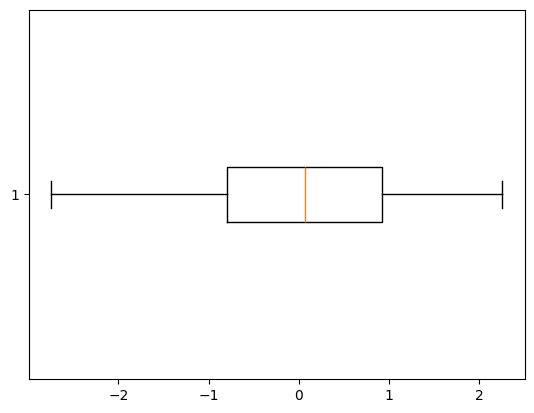

In [44]:
errors = regr.findErrors()
plt.boxplot(errors, orientation="horizontal")
...

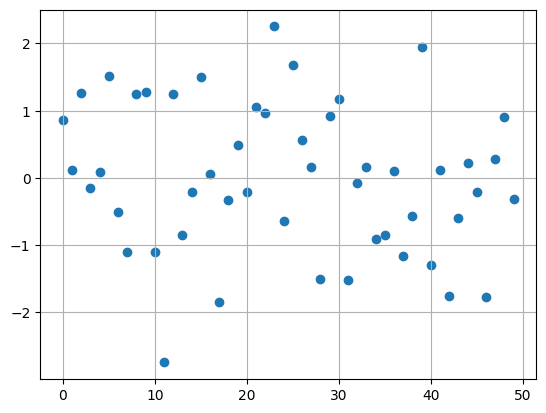

In [45]:
plt.scatter(np.arange(0, errors.shape[0]), errors)
plt.grid()

h) кросс-валидация регрессии

In [46]:
def calculateCVSS_R(X: np.ndarray, y: np.ndarray, batch_size: int) -> float:
    n = X.shape[0]
    cvss = 0
    for i in range(n // batch_size):
        cut_from = i * batch_size
        cut_to = (i + 1) * batch_size
        remained_X = np.concatenate([X[:cut_from], X[cut_to:]], axis=0)
        remained_y = np.concatenate([y[:cut_from], y[cut_to:]], axis=0)
        cutted_X = X[cut_from:cut_to]
        cutted_y = y[cut_from:cut_to]

        regr = Regressor(remained_X, remained_y, funcs)
        y_estim = regr.getPredictions(cutted_X)
        cvss_i = np.sum((y_estim - cutted_y) ** 2)
        cvss += cvss_i
    regr = Regressor(X, y, funcs)
    TSS = regr.findTSS()
    R_cv = (TSS - cvss) / TSS
    return R_cv

In [47]:
print(f"R_cv = {np.round(calculateCVSS_R(X, y, 1), precise)}")

R_cv = 0.829


f) проверка адекватности

In [48]:
def get_y(point: np.ndarray) -> float:
    avg = 2 + 3 * point[0] - 2 * point[1] + point[2] + point[3] - point[4]
    y = np.random.normal(loc=avg, scale=1.5)
    return y

In [49]:
point = np.array([0, 0, 0, 0, 0], dtype=float)
m = 5
measurements = np.array([get_y(point) for _ in range(m)])

var = np.var(measurements, ddof=1)
regr = Regressor(X, y, funcs)
RSS = regr.findRSS()
n = X.shape[0]
p = len(funcs)
delta = RSS / var / (n - p)

p_value = f.sf(delta, n - p, m - 1)
print(f"p_value = {np.round(p_value, precise)}; нельзя отклонить гипотезу о равенстве дисперсий")

p_value = 0.237; нельзя отклонить гипотезу о равенстве дисперсий


j)

In [50]:
funcs = [func0, func1, func2, func3, func4, func5]

regr = Regressor(sample[:, :-1], sample[:, -1], funcs)

regr.printRegr()
for i in range(len(funcs)):
    print(f"p-value для значимости {i}-ого коэффициента: {regr.checkCoefficientSignificance(i)}")

y = 1.834 + 3.586*x_1 + -2.466*x_2 + 1.24*x_3 + 0.661*x_4 + -0.964*x_5
p-value для значимости 0-ого коэффициента: 0.0
p-value для значимости 1-ого коэффициента: 0.0
p-value для значимости 2-ого коэффициента: 0.0
p-value для значимости 3-ого коэффициента: 0.0
p-value для значимости 4-ого коэффициента: 0.034
p-value для значимости 5-ого коэффициента: 0.006


In [56]:
not_significant = 4
funcs_new = [funcs[i] for i in range(len(funcs)) if i != not_significant]

regr = Regressor(X, y, funcs_new)
regr.printRegr()
for i in range(len(funcs_new)):
    print(f"p-value для значимости {i}-ого коэффициента: {regr.checkCoefficientSignificance(i)}")

y = 1.879 + 3.594*x_1 + -2.528*x_2 + 1.287*x_3 + -0.935*x_4
p-value для значимости 0-ого коэффициента: 0.0
p-value для значимости 1-ого коэффициента: 0.0
p-value для значимости 2-ого коэффициента: 0.0
p-value для значимости 3-ого коэффициента: 0.0
p-value для значимости 4-ого коэффициента: 0.01


In [57]:
print(f"R^2 = {regr.findRSquare()}")
funcs_narrow = [func0]
regr_narrow = Regressor(X, y, funcs_narrow)
regr_wide = Regressor(X, y, funcs_new)
print(f"p-value = {compareNarrowAndWideRegressions(regr_narrow, regr_wide)}; нельзя считать коэффициенты регрессии незначимыми")

R^2 = 0.851
p-value = 0.0; нельзя считать коэффициенты регрессии незначимыми


In [58]:
regr_narrow = Regressor(X, y, funcs_new)
regr_wide = Regressor(X, y, funcs)
print(f"p-value = {compareNarrowAndWideRegressions(regr_narrow, regr_wide)}; ")

p-value = 0.034; 


k) сравнение регрессий бутстрапом

In [59]:
def doBootstrapRegr(
        X: np.ndarray,
        y: np.ndarray,
        funcs_narrow: list["function"],
        funcs_wide: list["function"],
        times: int = 1000,
        beta: float = 0.95) -> tuple[float, float]:
    n = X.shape[0]
    deltas = []
    for i in range(times):
        sub_sample_inds = np.random.randint(0, n, size=n)
        regr_narrow = Regressor(X[sub_sample_inds], y[sub_sample_inds], funcs_narrow)
        regr_wide = Regressor(X[sub_sample_inds], y[sub_sample_inds], funcs_wide)

        RSS_narrow = regr_narrow.findRSS()
        RSS_wide = regr_wide.findRSS()

        diff = RSS_narrow - RSS_wide

        deltas.append(diff)

    deltas = np.array(deltas)
    deltas = np.sort(deltas)

    regr_narrow = Regressor(X, y, funcs_narrow)
    regr_wide = Regressor(X, y, funcs_wide)
    RSS_narrow = regr_narrow.findRSS()
    RSS_wide = regr_wide.findRSS()

    diff_estim = RSS_narrow - RSS_wide

    right_bound = diff_estim - deltas[int((1 - beta) * times)]
    left_bound = diff_estim - deltas[times - 1]

    return (left_bound, right_bound)

In [60]:
left_bound, right_bound = doBootstrapRegr(X, y, funcs_new, funcs)
print(f"({np.round(left_bound, precise)}, {np.round(right_bound, precise)})")
print(f"так как ноль принадлежит интервалу, то можно считать, что вклад удалённого коэффициента незначим")

(-28.168, 6.231)
так как ноль принадлежит интервалу, то можно считать, что вклад удалённого коэффициента незначим
